# Application avec le jeu de données Car Evaluation

# Importation des données et librairies
(lien du jeu de données: https://archive.ics.uci.edu/dataset/19/car+evaluation)

In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
sns.set(style="whitegrid")
np.random.seed(42)

# Importation des données depuis ucimlrepo
from ucimlrepo import fetch_ucirepo

# Chargement du dataset Car Evaluation
car_evaluation = fetch_ucirepo(id=19)

# Les features et la cible sont déjà sous forme de DataFrame
X = car_evaluation.data.features  # DataFrame des variables explicatives
y = car_evaluation.data.targets   # DataFrame de la variable cible

# Pour avoir un seul DataFrame combiné :
df = pd.concat([X, y], axis=1)

# Affichage des premières lignes
print(df.head())


  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


<div class="alert alert-block alert-info">
On importe les données depuis la librairie ucimlrepo et on applique la seed sur 42 pour la reproductibilité des résultats (sur les méthodes du au hasards)

On se trouve dans un problème de classification: avec une variable qualitative (multiple ordinale) à essayer de prédire, qui est ici la variable "class"
</div>

# Visualisation

In [4]:
#nombre d'observations et de variables
print(f"Nombre d'observations : {df.shape[0]}")
print(f"Nombre de variables : {df.shape[1]}")
#variables explicatives
print(f"Variables explicatives : {df.columns[:-1].tolist()}")
#variable d'intérêt
print(f"Variable d'intérêt : {df.columns[-1]}")
#donnée manquantes
print(f"Données manquantes : {df.isnull().sum().sum()}")

Nombre d'observations : 1728
Nombre de variables : 7
Variables explicatives : ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
Variable d'intérêt : class
Données manquantes : 0


Il n'y a pas de données manquantes

In [5]:
df.describe(include='all')
#type des variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


Analyse des variables catégorielles
- nombre d'occurence par catégorie

In [6]:
#analyse des variables explicatives catégorielles
categorical_cols = df.select_dtypes(include=['object']).columns

for col in df.columns:
    print(f"Table de fréquences pour '{col}':")
    print(df[col].value_counts())
    print("-" * 40)

Table de fréquences pour 'buying':
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
----------------------------------------
Table de fréquences pour 'maint':
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
----------------------------------------
Table de fréquences pour 'doors':
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
----------------------------------------
Table de fréquences pour 'persons':
persons
2       576
4       576
more    576
Name: count, dtype: int64
----------------------------------------
Table de fréquences pour 'lug_boot':
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
----------------------------------------
Table de fréquences pour 'safety':
safety
low     576
med     576
high    576
Name: count, dtype: int64
----------------------------------------
Table de fréquences pour 'class':
class
unacc    1210
acc       384
good     

<div class="alert alert-block alert-info">  

1. Buying: 
Cette variable dit combien la voiture coûte à l’achat. Les valeurs sont : très cher, cher, moyen, ou pas cher.

2. maint :
C’est le prix pour entretenir la voiture. Comme buying, on a : très cher, cher, moyen ou pas cher.

3. doors :
C’est le nombre de portes de la voiture. On peut avoir : 2, 3, 4 ou 5 portes et plus.

4. persons :
C’est combien de personnes peuvent monter dans la voiture. Les valeurs sont : 2, 4 ou plus.
5. lug_boot :
C’est la taille du coffre. On peut avoir : petit, moyen ou grand.
6. safety :
C’est le niveau de sécurité. Les valeurs sont : faible, moyen ou élevé.
7. class (la cible) :
C’est le résultat final, une sorte de note de la voiture. Les valeurs sont : pas acceptable, acceptable, bon, très bon.

</div>


### visualisation des données catégorielles

C:\Users\speye\AppData\Local\Temp\ipykernel_1876\875359168.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\speye\AppData\Local\Temp\ipykernel_1876\875359168.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\speye\AppData\Local\Temp\ipykernel_1876\875359168.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\speye\AppData\Local\Temp\ipykernel_1876\875359168.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


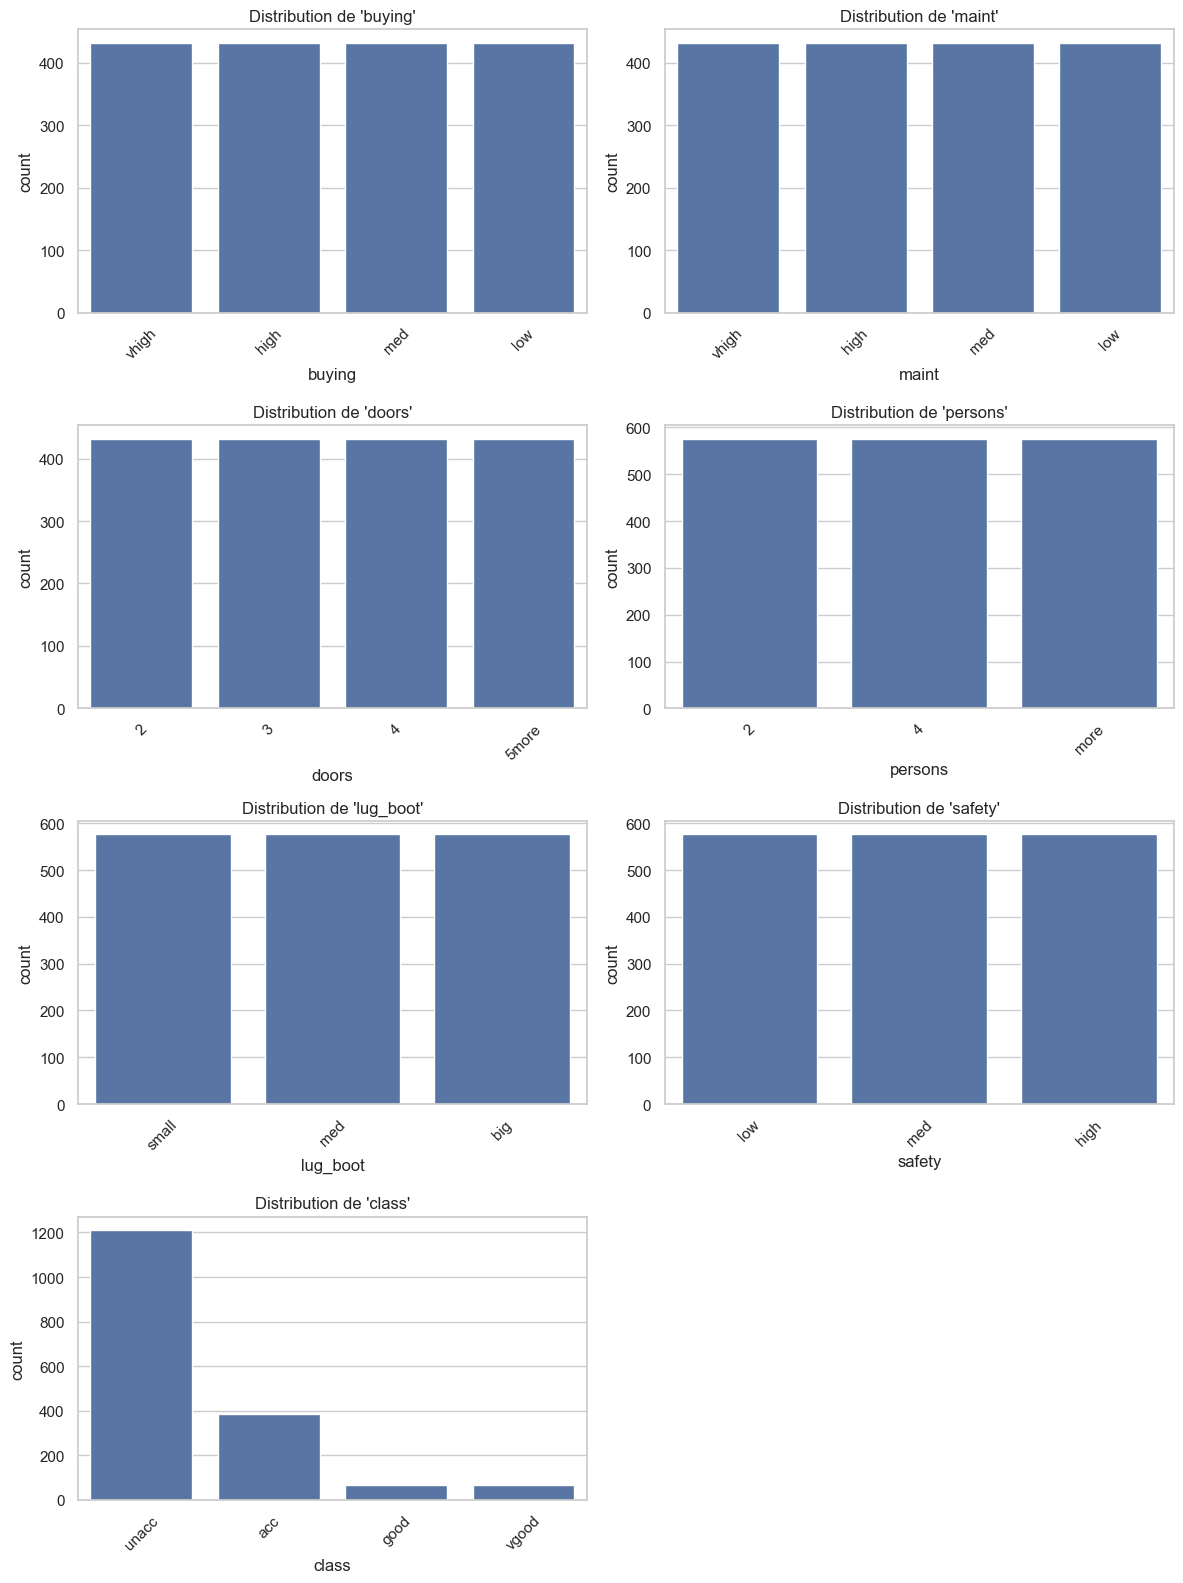

In [7]:
import math

n = len(categorical_cols)
ncols = 2  # nombre de colonnes de la grille
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))

for i, col in enumerate(categorical_cols):
    ax = axes.flat[i]
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"Distribution de '{col}'")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Si il y a des cases vides, on les masque
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.show()

toutes les variables sont équilibrés sauf la variables d'intérêt, le jeu de donnée ne contient aucune variable numérique

on veux tester les corrélations, il faut pour cela convertir les variable catégorielle en variable numérique

In [8]:
df_copy = df.copy()
#conversion des variables catégorielles en numériques
df_copy['buying_num'] = df_copy['buying'].map({'vhigh': 3, 'high': 2, 'med': 1, 'low': 0})
df_copy['maint_num'] = df_copy['maint'].map({'vhigh': 3, 'high': 2, 'med': 1, 'low': 0})
df_copy['doors_num'] = df_copy['doors'].map({'2': 2, '3': 3, '4': 4, '5more': 5})
df_copy['persons_num'] = df_copy['persons'].map({'2': 2, '4': 4, 'more': 6})
df_copy['lug_boot_num'] = df_copy['lug_boot'].map({'small': 1, 'med': 2, 'big': 3})
df_copy['safety_num'] = df_copy['safety'].map({'low': 1, 'med': 2, 'high': 3})
df_copy['class_num'] = df_copy['class'].map({'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3})

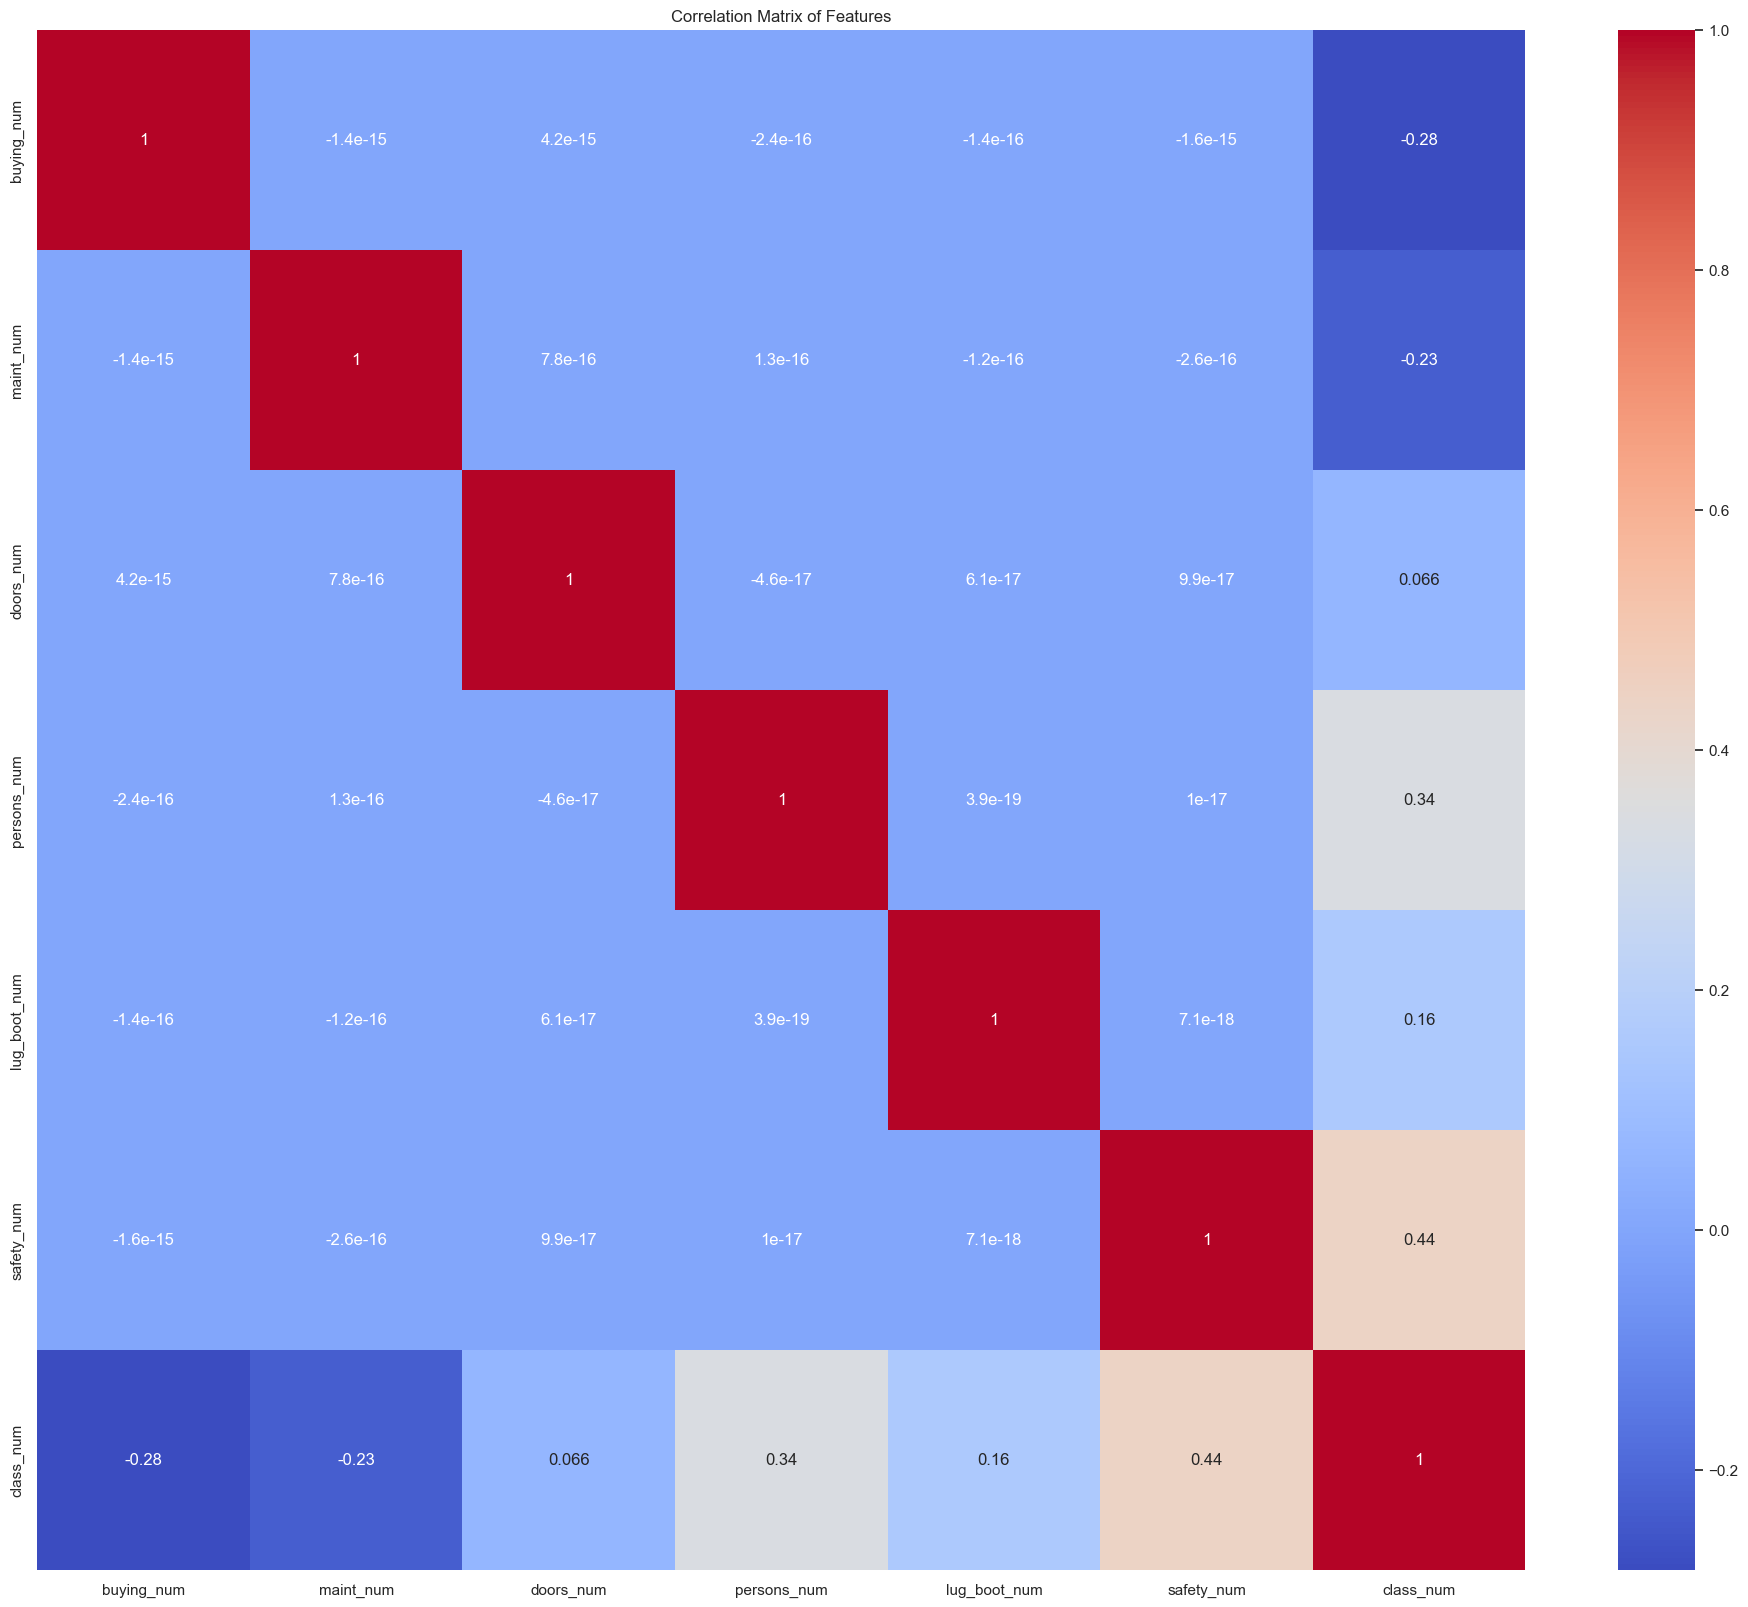

In [9]:
# Display correlation matrix of the features
plt.figure(figsize=(24, 20))
sns.heatmap(df_copy.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

les variables ne sont pas très corrélés entre elles, seul la variable class_num peux semble avoir quelques corrélation relativement faible avec certaines variables

# Formatage des données
<div class="alert alert-block alert-info">

- vérification de la qualité des données
- Supprimer les colonnes inutiles (non tout a l'air utile)
- Séparer les variables numériques et catégorielles
- Gérer les valeurs manquantes
- Encoder les variables catégorielles
<div>

In [10]:
#vérification de la qualité des données
# 1. Espaces invisibles (début/fin)
for col in df_copy.select_dtypes(include='object'):
    if df_copy[col].str.contains(r'^\s+|\s+$').any():
        print(f"Espaces invisibles détectés dans la colonne : {col}")

# 2. Colonnes mal encodées (ex : numériques en object)
for col in df_copy.columns:
    if df_copy[col].dtype == 'object':
        try:
            pd.to_numeric(df_copy[col])
            print(f"Colonne potentiellement mal encodée (numérique en string) : {col}")
        except:
            pass

# 3. Nombres stockés comme string
for col in df_copy.select_dtypes(include='object'):
    if df_copy[col].str.match(r'^-?\d+(\.\d+)?$').all():
        print(f"Nombres stockés comme string dans : {col}")

# 4. Caractères spéciaux
import re
for col in df_copy.select_dtypes(include='object'):
    if df_copy[col].str.contains(r'[^a-zA-Z0-9\s]').any():
        print(f"Caractères spéciaux détectés dans : {col}")

la qualité des données est correctes, sans colonne a supprimé et les variables catégorielles sont déjas encodé

Maintenant, on sépare y (cible) et X (explicatives)

In [11]:
y = df_copy['class_num']
x = df_copy.drop(columns=['class', 'class_num'])
#drop des colonnes d'origine
x = x.drop(columns=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])
print(x.head())
print(y.value_counts())

   buying_num  maint_num  doors_num  persons_num  lug_boot_num  safety_num
0           3          3          2            2             1           1
1           3          3          2            2             1           2
2           3          3          2            2             1           3
3           3          3          2            2             2           1
4           3          3          2            2             2           2
class_num
0    1210
1     384
2      69
3      65
Name: count, dtype: int64


<div class="alert alert-block alert-info">

On peut normaliser les données c'est utiles pour les méthodes suivantes:
- KNN 
- SVM 
- Régression linéaire / logistique
- PCA 

</div>

In [12]:
#normalisation des données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x.head()

,buying_num,maint_num,doors_num,persons_num,lug_boot_num,safety_num
0,3,3,2,2,1,1
1,3,3,2,2,1,2
2,3,3,2,2,1,3
3,3,3,2,2,2,1
4,3,3,2,2,2,2


La normalisation (centrage-reduction) ici fait peu de sens car on n'a que des données catégorielles

<div class="alert alert-block alert-info">

On ne peut pas appliquer ici une ACP (PCA), car les données sont qualitatives : même si elles sont recodées en numérique, ce n’est pas approprié. La méthode adaptée serait plutôt une analyse des correspondances multiples (MCA, Multiple Correspondence Analysis), mais cette méthode ne sera pas utilisée dans ce projet.

</div>

# sépartion du jeu de données (train/test)
pour un split 80/20:

In [13]:
# Split into training and testing sets (80% train, 20% test)
X_train_hard, X_test_hard, y_train_hard, y_test_hard = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("X_train_hard shape:", X_train_hard.shape)
print("y_train_hard shape:", y_train_hard.shape)
print()
print("X_test_hard shape:", X_test_hard.shape)
print("y_test_hard shape:", y_test_hard.shape)

X_train_hard shape: (1382, 6)
y_train_hard shape: (1382,)

X_test_hard shape: (346, 6)
y_test_hard shape: (346,)


pour un split 70/30

In [14]:
# Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)

# Display the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print()
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1209, 6)
y_train shape: (1209,)

X_test shape: (519, 6)
y_test shape: (519,)


# mise en place des modèles

<div class="alert alert-block alert-info">

on va utilier les modèles :
- regression logistique
- Knn (plus proche voisins)
- Cart (Arbre de décision)
- Random Forest
- SVM
- XGBOOST   
comme on se trouve dans le cas de prédiction de variable qualitatives

</div>

In [28]:
# Define a dictionary of models to train and evaluate {key: model name, value: model instance}
models = {
    "Logistic Regression": LogisticRegression(max_iter=20, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=20, random_state=42),
    "SVM": SVC(kernel="rbf", gamma="scale", random_state=42)
}

#on rajoute le modèle XGboost
from xgboost import XGBClassifier
models["XGBoost"] = XGBClassifier(random_state=42)

# 5 Comparaison des modèles
jeu de donnée normalisation (même si la normalisation n'a rien changer) sur un train-test 80/20

In [29]:
results_hard = {}
for name, model in models.items():
    model.fit(X_train_hard, y_train_hard) # Train the model on the training data
    preds_hard = model.predict(X_test_hard) # Make predictions on the test set

    # Calculate evaluation metrics for the model
    acc_hard = accuracy_score(y_test_hard, preds_hard)
    precision_hard = precision_score(y_test_hard, preds_hard, average="macro")
    recall_hard = recall_score(y_test_hard, preds_hard, average="macro")
    f1_hard = f1_score(y_test_hard, preds_hard, average="macro")
    cm_hard = confusion_matrix(y_test_hard, preds_hard)

    
    results_hard[name] = {
        "accuracy": acc_hard,
        "precision": precision_hard,
        "recall": recall_hard,
        "f1": f1_hard,
        "confusion_matrix": cm_hard,
    }
    
# Create a DataFrame from the results dictionary for better visualization
results_hard = pd.DataFrame(results_hard).T # Transpose the DataFrame to have models as rows and metrics as columns
results_hard.head(6)

c:\Users\speye\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1,confusion_matrix
Logistic Regression,0.815029,0.753432,0.675282,0.705287,"[[218, 14, 1, 2], [35, 46, 1, 1], [1, 4, 5, 1]..."
KNN,0.945087,0.902484,0.774032,0.82469,"[[235, 0, 0, 0], [8, 75, 0, 0], [0, 5, 6, 0], ..."
Decision Tree,0.965318,0.880286,0.909059,0.881536,"[[235, 0, 0, 0], [2, 75, 6, 0], [0, 1, 10, 0],..."
Random Forest,0.956647,0.854868,0.900023,0.867882,"[[235, 0, 0, 0], [4, 72, 6, 1], [0, 0, 10, 1],..."
SVM,0.965318,0.901159,0.920753,0.907346,"[[235, 0, 0, 0], [5, 74, 4, 0], [0, 0, 10, 1],..."
XGBoost,0.985549,0.930208,0.973246,0.946294,"[[235, 0, 0, 0], [0, 79, 4, 0], [0, 0, 11, 0],..."


Index(['accuracy', 'precision', 'recall', 'f1', 'confusion_matrix'], dtype='object')


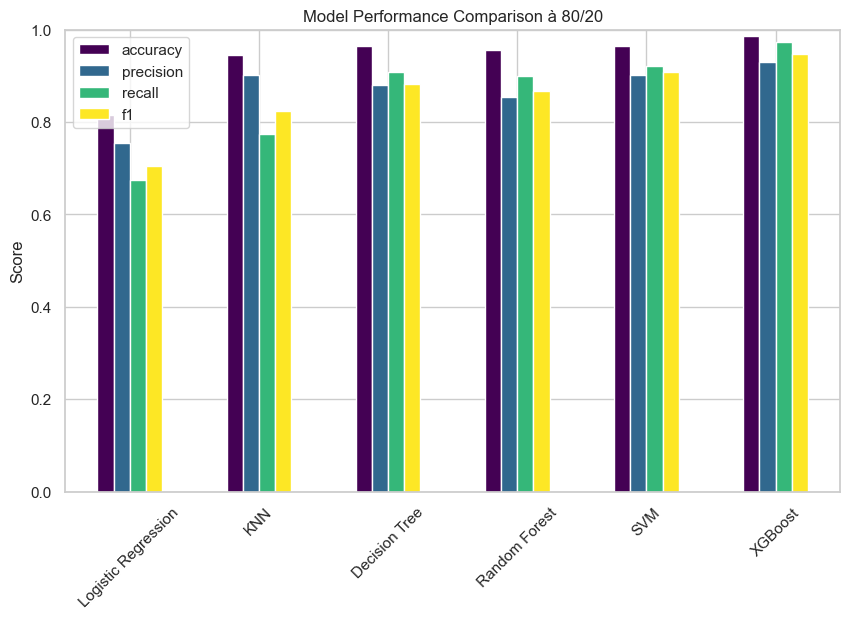

In [30]:
# Plotting the results
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
print(results_hard.columns)
results_hard[metrics_to_plot].plot(kind="bar", colormap="viridis", figsize=(10, 6))
plt.title("Model Performance Comparison à 80/20")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

jeu de données normalisé (même si la normalisation n'a rien changer) sur un train-test 70/30

In [31]:
results_hard2 = {}
for name, model in models.items():
    model.fit(X_train, y_train) # Train the model on the training data
    preds_hard2 = model.predict(X_test) # Make predictions on the test set

    # Calculate evaluation metrics for the model
    acc_hard = accuracy_score(y_test, preds_hard2)
    precision_hard = precision_score(y_test, preds_hard2, average="macro")
    recall_hard = recall_score(y_test, preds_hard2, average="macro")
    f1_hard = f1_score(y_test, preds_hard2, average="macro")
    cm_hard = confusion_matrix(y_test, preds_hard2)

    
    results_hard2[name] = {
        "accuracy": acc_hard,
        "precision": precision_hard,
        "recall": recall_hard,
        "f1": f1_hard,
        "confusion_matrix": cm_hard,
    }
    
# Create a DataFrame from the results dictionary for better visualization
results_hard2 = pd.DataFrame(results_hard2).T # Transpose the DataFrame to have models as rows and metrics as columns
results_hard2.head(6)

c:\Users\speye\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1,confusion_matrix
Logistic Regression,0.822736,0.728167,0.669373,0.693056,"[[333, 18, 3, 4], [47, 68, 2, 1], [1, 9, 8, 1]..."
KNN,0.953757,0.93366,0.820769,0.865817,"[[357, 1, 0, 0], [9, 108, 0, 1], [0, 8, 11, 0]..."
Decision Tree,0.967245,0.914021,0.919851,0.916229,"[[356, 2, 0, 0], [5, 108, 4, 1], [0, 1, 17, 1]..."
Random Forest,0.959538,0.876092,0.901658,0.887386,"[[357, 1, 0, 0], [5, 104, 5, 4], [0, 1, 17, 1]..."
SVM,0.961464,0.908381,0.909458,0.907971,"[[353, 5, 0, 0], [6, 109, 3, 0], [0, 0, 17, 2]..."
XGBoost,0.980732,0.915883,0.941559,0.927587,"[[357, 1, 0, 0], [0, 113, 4, 1], [0, 1, 17, 1]..."


Index(['accuracy', 'precision', 'recall', 'f1', 'confusion_matrix'], dtype='object')


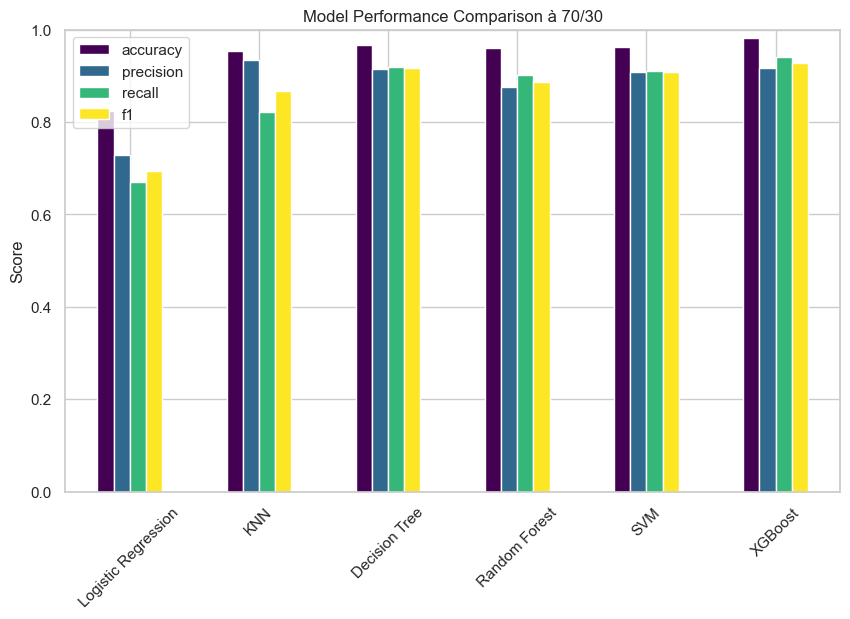

In [32]:
# Plotting the results
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
print(results_hard2.columns)
results_hard2[metrics_to_plot].plot(kind="bar", colormap="viridis", figsize=(10, 6))
plt.title("Model Performance Comparison à 70/30")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

<div class="alert alert-block alert-info">

on va tester une autre approche pour optimiser les hyperparamètres de nos modèles : la recherche en grille (GridSearchCV) de scikit-learn, qui permet d'explorer systématiquement différentes combinaisons d'hyperparamètres pour trouver la meilleure configuration. met un peu de temp (~5min max) à tourner et requiert au moins 3 coeur sur son pc. les résultars sont issue de la moyenne sur plusieurs cross-validation

</div>

In [33]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Dictionnaire des grilles de paramètres possible pour chaque modèle
param_grids = {
    "Logistic Regression": {
        "max_iter": [50, 100, 200],
        "C": [0.01, 0.1, 1, 10]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },
    "Decision Tree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
    "n_estimators": [20, 50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10, 20]
},
    "SVM": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "n_estimators": [20, 50, 100],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2]
    }
}

best_models = {}
for name, model in models.items():
    print(f"Optimisation de {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring="accuracy", n_jobs=3) #5-fold cross-validation, évaluation basée sur l'accuracy, utilisation de 3 cœurs pour accélérer le processus
    grid.fit(X_train_hard, y_train_hard)
    best_models[name] = grid.best_estimator_
    print(f"Meilleurs paramètres pour {name} : {grid.best_params_}")
    print(f"Meilleure accuracy (cross-val) : {grid.best_score_:.3f}\n")

# Utilise best_models à la place de models pour entraîner et évaluer tes modèles optimisés

Optimisation de Logistic Regression...
Meilleurs paramètres pour Logistic Regression : {'C': 10, 'max_iter': 50}
Meilleure accuracy (cross-val) : 0.834

Optimisation de KNN...
Meilleurs paramètres pour KNN : {'n_neighbors': 7, 'weights': 'distance'}
Meilleure accuracy (cross-val) : 0.955

Optimisation de Decision Tree...
Meilleurs paramètres pour Decision Tree : {'max_depth': None, 'min_samples_split': 2}
Meilleure accuracy (cross-val) : 0.973

Optimisation de Random Forest...
Meilleurs paramètres pour Random Forest : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Meilleure accuracy (cross-val) : 0.980

Optimisation de SVM...
Meilleurs paramètres pour SVM : {'C': 10, 'gamma': 'scale'}
Meilleure accuracy (cross-val) : 0.983

Optimisation de XGBoost...
Meilleurs paramètres pour XGBoost : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50}
Meilleure accuracy (cross-val) : 0.990



on affiche les résultats des meilleurs modèles trouvé sur les jeux de test initiaux (dans le cas 80/20) sur un barplot

                     accuracy precision    recall        f1
Logistic Regression  0.820809  0.761225     0.693  0.717879
KNN                  0.947977  0.905411   0.85178  0.874903
Decision Tree        0.965318  0.880286  0.909059  0.881536
Random Forest        0.962428   0.85712  0.906047  0.872338
SVM                  0.971098   0.90528  0.958186  0.921444
XGBoost              0.982659   0.91871  0.970234  0.936869


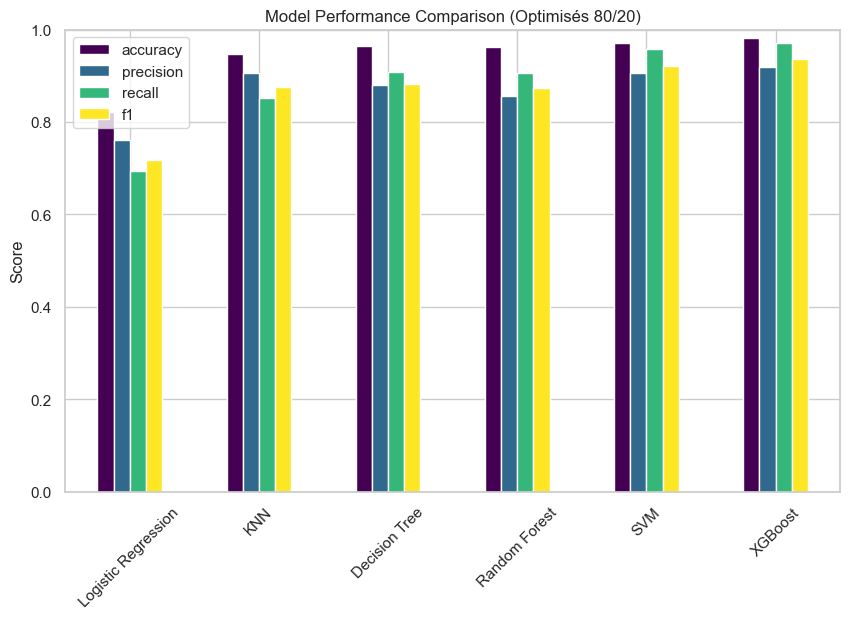

In [21]:
# Évaluation et bar plot à partir des modèles optimisés (best_models)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results_best = {}
for name, model in best_models.items():
    preds = model.predict(X_test_hard)
    acc = accuracy_score(y_test_hard, preds)
    precision = precision_score(y_test_hard, preds, average="macro")
    recall = recall_score(y_test_hard, preds, average="macro")
    f1 = f1_score(y_test_hard, preds, average="macro")
    cm = confusion_matrix(y_test_hard, preds)
    results_best[name] = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }

results_best_df = pd.DataFrame(results_best).T
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
print(results_best_df[metrics_to_plot])
results_best_df[metrics_to_plot].plot(kind="bar", colormap="viridis", figsize=(10, 6))
plt.title("Model Performance Comparison (Optimisés 80/20)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

on voit sur le barplot que XGboost reste le meilleur modèle sur tous les critères d'évaluation

### pour aller plus loin

        Feature  Importance
3   persons_num    0.376827
5    safety_num    0.252803
0    buying_num    0.130077
1     maint_num    0.124508
4  lug_boot_num    0.087601
2     doors_num    0.028184


C:\Users\speye\AppData\Local\Temp\ipykernel_1876\335792066.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")


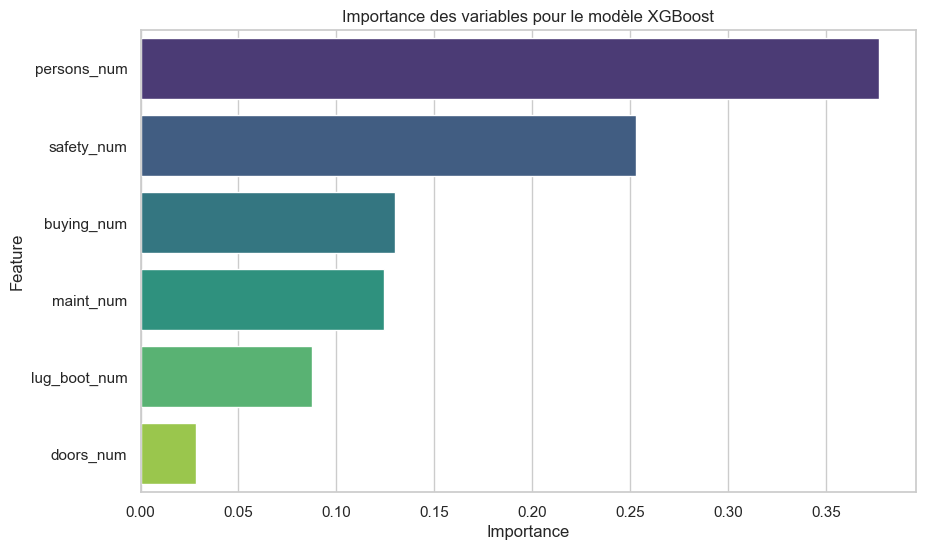

    class_num       Feature  Odds Ratio
3           3    buying_num    0.096114
7           3     maint_num    0.226792
6           2     maint_num    0.236172
21          1    safety_num    0.248127
2           2    buying_num    0.269775
17          1  lug_boot_num    0.567462
11          3     doors_num    1.577250
14          2   persons_num    2.090353
5           1     maint_num    2.950991
1           1    buying_num    4.228216
15          3   persons_num    5.028928
19          3  lug_boot_num    5.581725
23          3    safety_num  136.214359


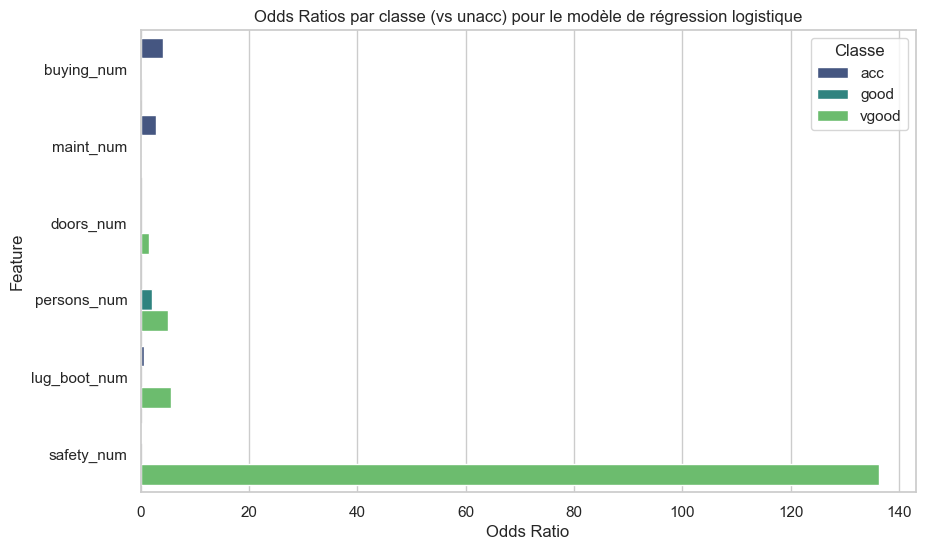

In [41]:
#estimer les variables les plus importantes pour le modèle XGBoost
xgb_model = best_models["XGBoost"]
importances = xgb_model.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances
})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
print(feature_importance_df)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Importance des variables pour le modèle XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

#estimer les variables les OR avec le modèle de régression logistique par classe de la variable cible "class_num"
from sklearn.linear_model import LogisticRegression
logreg_model = best_models["Logistic Regression"]
odds_ratios = np.exp(logreg_model.coef_)
feature_names = x.columns
odds_ratios_df = pd.DataFrame(odds_ratios, columns=feature_names)
odds_ratios_df["class_num"] = logreg_model.classes_
odds_ratios_df = odds_ratios_df.melt(id_vars="class_num", var_name="Feature", value_name="Odds Ratio")
# suppression des OR non significatifs 
odds_ratios_df = odds_ratios_df[(odds_ratios_df["Odds Ratio"] > 1.5) | (odds_ratios_df["Odds Ratio"] < (1/1.5))] # Seuil arbitraire pour ne garder que les OR les plus éloignés de 1 (significatifs)
# ne pas afficher les OR pour la classe de référence (unacc)
odds_ratios_df = odds_ratios_df[odds_ratios_df["class_num"] != 0] # Supposant que "unacc" est la classe de référence (0)

sorted_odds_ratios_df = odds_ratios_df.sort_values(by="Odds Ratio", ascending=True)

print(sorted_odds_ratios_df)
# Dictionnaire de correspondance
class_labels = {0: "unacc", 1: "acc", 2: "good", 3: "vgood"}

# Remplacer les valeurs numériques par les labels
odds_ratios_df["class_label"] = odds_ratios_df["class_num"].map(class_labels)

# Filtrer pour ne pas afficher la classe de référence
odds_ratios_df = odds_ratios_df[odds_ratios_df["class_label"] != "unacc"]

plt.figure(figsize=(10, 6))
sns.barplot(x="Odds Ratio", y="Feature", hue="class_label", data=odds_ratios_df, palette="viridis")
plt.title("Odds Ratios par classe (vs unacc) pour le modèle de régression logistique")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.legend(title="Classe")
plt.show()

# Conclusion
<div class="alert alert-block alert-info"> 

Les modèles présentés sont testés sous trois formes :
- Un premier entraînement des modèles sur 80% du jeu de données puis testés sur les 20% restants
- Un deuxième entraînement des modèles sur 70% du jeu de données puis testés sur les 30% restants
- Un troisième entraînement automatique qui teste les modèles sur une liste de paramètres possibles et choisit automatiquement le meilleur modèle selon la moyenne d'accuracy obtenue sur une cross-validation* (dans une répartition train/test 80:20)

On retient de tous ces entraînements que dans l'ensemble les modèles ressortent des résultats bons supérieurs à 80% de taux de bonnes prédictions (accuracy) avec sur tous les entraînements toujours XGBoost qui reste au sommet à environ 98% de précision.

On peut d'ailleurs retenir les paramètres suivants qui maximisent les résultats de XGBoost :
Meilleurs paramètres pour XGBoost : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50}

## Pour aller plus loin:
On peut essayer d'estimer les variables les plus utilisé par modèles:   

avec Xgboost le modèle, le plus perfomant, les variables les plus importantes pour les prédictions sont :
- le nombre de personnes max par voiture (persons expliquant 37% de la prédiction)
- le niveau de sécurité (safety expliquant 25% de la prédiction)
- et en 3eme le prix à l'achat (buying expliquant 13% de la prédiction)

on peut aussi à partir de la régression logistique calculé les odds ratio OR (un estimateur du risque relatif RR) à partir de la classe de référence unacc (0) comparé au autre classes:
OR > 1 : la variable augmente la probabilité d’être dans la classe cible (vs unacc).
OR < 1 : la variable diminue la probabilité d’être dans la classe cible (vs unacc).
Il y'a trop d'Odds ratio pour tous les interprété mais on peut cité:
3  persons_num    5.028928
3  lug_boot_num    5.581725
3    safety_num  136.214359
ces variables ont tous des effet risque fort (surtout sur la variable safety qui est extrêment élevé) avec un OR élevé lors de la comparaison de 3 vs 0


*cross-validation: La cross-validation permet de tester le modèle sur plusieurs sous-ensembles du jeu de données pour avoir une évaluation robuste et générale de ses performances.*
</div> 